<a href="https://colab.research.google.com/github/diyasonly19/northstar_database/blob/main/SQL_IN_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install and load packages
install.packages(c('sqldf','ggplot2','dplyr','tidyr','lubridate','scales'))
library(sqldf); library(ggplot2); library(dplyr)
library(tidyr); library(lubridate); library(scales)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [3]:
# Loading datasets directly from GitHub repository

BASE_URL <- "https://raw.githubusercontent.com/diyasonly19/northstar_database/main/northstar_dataset/"

orders <- read.csv(paste0(BASE_URL, "orders.csv"))
deliveries <- read.csv(paste0(BASE_URL, "deliveries.csv"))
customers <- read.csv(paste0(BASE_URL, "customers.csv"))
drivers <- read.csv(paste0(BASE_URL, "drivers.csv"))
vehicles <- read.csv(paste0(BASE_URL, "vehicles.csv"))
complaints <- read.csv(paste0(BASE_URL, "complaints.csv"))
incidents <- read.csv(paste0(BASE_URL, "incidents.csv"))
hubs <- read.csv(paste0(BASE_URL, "hubs.csv"))

cat("All datasets loaded successfully!\n")

All datasets loaded successfully!


In [4]:
# ── FIX ZONE INCONSISTENCIES

# toupper() converts everything to UPPERCASE
# trimws() removes any accidental spaces before/after the text
# This makes "north", "North", "NORTH", "north " all become "NORTH"

orders$pickup_zone     <- toupper(trimws(orders$pickup_zone))
orders$dropoff_zone    <- toupper(trimws(orders$dropoff_zone))
drivers$base_zone      <- toupper(trimws(drivers$base_zone))
vehicles$assigned_zone <- toupper(trimws(vehicles$assigned_zone))
customers$home_zone    <- toupper(trimws(customers$home_zone))

# Check it worked — should now show clean consistent values
cat("=== Pickup zones after fix ===\n")
print(unique(orders$pickup_zone))

cat("\n=== Driver base zones after fix ===\n")
print(unique(drivers$base_zone))

=== Pickup zones after fix ===
[1] "AIRPORT"   "NORTH"     "WEST"      "RIVERSIDE" "CENTRAL"   "SOUTH"    
[7] "EAST"      "CTR"      

=== Driver base zones after fix ===
[1] "AIRPORT"   "CENTRAL"   "NORTH"     "SOUTH"     "WEST"      "EAST"     
[7] "RIVERSIDE" "CTR"      


In [5]:
# ── EXPLORATORY DATA ANALYSIS

# STEP 1: Check the size of each dataset (rows and columns)
cat("=== DATASET DIMENSIONS ===\n")
cat("Orders:      ", nrow(orders),     "rows,", ncol(orders),     "columns\n")
cat("Deliveries:  ", nrow(deliveries), "rows,", ncol(deliveries), "columns\n")
cat("Customers:   ", nrow(customers),  "rows,", ncol(customers),  "columns\n")
cat("Drivers:     ", nrow(drivers),    "rows,", ncol(drivers),    "columns\n")
cat("Vehicles:    ", nrow(vehicles),   "rows,", ncol(vehicles),   "columns\n")
cat("Complaints:  ", nrow(complaints), "rows,", ncol(complaints), "columns\n")
cat("Incidents:   ", nrow(incidents),  "rows,", ncol(incidents),  "columns\n")
cat("Hubs:        ", nrow(hubs),       "rows,", ncol(hubs),       "columns\n")

=== DATASET DIMENSIONS ===
Orders:       1250 rows, 11 columns
Deliveries:   950 rows, 13 columns
Customers:    650 rows, 9 columns
Drivers:      170 rows, 8 columns
Vehicles:     120 rows, 8 columns
Complaints:   320 rows, 10 columns
Incidents:    280 rows, 7 columns
Hubs:         8 rows, 5 columns


In [6]:
# STEP 2: Look at the structure of key tables
# str() shows column names, data types, and sample values
cat("=== ORDERS STRUCTURE ===\n")
str(orders)

cat("\n=== DELIVERIES STRUCTURE ===\n")
str(deliveries)

cat("\n=== COMPLAINTS STRUCTURE ===\n")
str(complaints)

=== ORDERS STRUCTURE ===
'data.frame':	1250 obs. of  11 variables:
 $ order_id             : chr  "O00001" "O00002" "O00003" "O00004" ...
 $ customer_id          : chr  "C0292" "C0459" "C0161" "C0520" ...
 $ service_type         : chr  "Passenger" "Passenger" "Passenger" "Parcel" ...
 $ order_created_at     : chr  "2024-08-20 14:43:00" "2024-05-14 22:16:00" "2025-09-02 14:37:00" "2025-01-11 17:15:00" ...
 $ promised_window_hours: int  6 24 4 2 12 1 2 4 12 6 ...
 $ pickup_zone          : chr  "AIRPORT" "NORTH" "WEST" "RIVERSIDE" ...
 $ dropoff_zone         : chr  "SOUTH" "AIRPORT" "AIRPORT" "NORTH" ...
 $ priority_level       : chr  "Medium" "Low" "High" "Medium" ...
 $ order_value          : num  126.7 109.3 33.5 10 125.6 ...
 $ booking_channel      : chr  "App" "App" "Phone" "App" ...
 $ special_handling_flag: int  0 0 0 1 0 1 0 0 0 0 ...

=== DELIVERIES STRUCTURE ===
'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004

In [7]:

# STEP 3: Count missing values in each table
# This is critical — missing data can skew your analysis

count_missing <- function(df, name) {
  total <- sum(is.na(df))
  cat(name, "— missing values:", total, "\n")
}

cat("=== MISSING VALUES PER TABLE ===\n")
count_missing(orders,     "Orders    ")
count_missing(deliveries, "Deliveries")
count_missing(customers,  "Customers ")
count_missing(drivers,    "Drivers   ")
count_missing(vehicles,   "Vehicles  ")
count_missing(complaints, "Complaints")
count_missing(incidents,  "Incidents ")

=== MISSING VALUES PER TABLE ===
Orders     — missing values: 0 
Deliveries — missing values: 14 
Customers  — missing values: 20 
Drivers    — missing values: 7 
Vehicles   — missing values: 4 
Complaints — missing values: 16 
Incidents  — missing values: 17 


In [8]:
# STEP 4: Summary statistics for numeric columns
# This gives min, max, mean, median for every number column

cat("=== ORDERS SUMMARY ===\n")
summary(orders[, c("order_value", "promised_window_hours")])

cat("\n=== DELIVERIES SUMMARY ===\n")
summary(deliveries[, c("route_distance_km", "fuel_or_charge_cost",
                        "customer_rating_post_delivery",
                        "manual_route_override_count")])

cat("\n=== COMPLAINTS SUMMARY ===\n")
summary(complaints[, c("resolution_days", "compensation_amount")])

=== ORDERS SUMMARY ===


  order_value     promised_window_hours
 Min.   :  2.04   Min.   : 1.000       
 1st Qu.: 47.91   1st Qu.: 4.000       
 Median : 76.53   Median : 6.000       
 Mean   : 91.05   Mean   : 7.622       
 3rd Qu.:121.10   3rd Qu.:12.000       
 Max.   :510.06   Max.   :24.000       


=== DELIVERIES SUMMARY ===


 route_distance_km fuel_or_charge_cost customer_rating_post_delivery
 Min.   : 1.200    Min.   : 2.500      Min.   :1.000                
 1st Qu.: 9.135    1st Qu.: 9.925      1st Qu.:3.360                
 Median :12.840    Median :12.645      Median :4.040                
 Mean   :13.909    Mean   :12.841      Mean   :3.865                
 3rd Qu.:16.835    3rd Qu.:15.697      3rd Qu.:4.550                
 Max.   :41.940    Max.   :29.430      Max.   :5.000                
                                       NA's   :14                   
 manual_route_override_count
 Min.   :0.0000             
 1st Qu.:0.0000             
 Median :1.0000             
 Mean   :0.9695             
 3rd Qu.:2.0000             
 Max.   :7.0000             
                            


=== COMPLAINTS SUMMARY ===


 resolution_days  compensation_amount
 Min.   : 1.000   Min.   : 0.000     
 1st Qu.: 3.750   1st Qu.: 8.822     
 Median : 7.000   Median :18.405     
 Mean   : 7.928   Mean   :20.257     
 3rd Qu.:11.000   3rd Qu.:29.145     
 Max.   :25.000   Max.   :61.850     
                  NA's   :16         

In [9]:
# STEP 5: Check for inconsistent text values
# The README warned us the data has inconsistent categories
# For example "North", "north", "NORTH" would all be treated differently

cat("=== UNIQUE ZONE VALUES (orders - pickup_zone) ===\n")
print(unique(orders$pickup_zone))

cat("\n=== UNIQUE ZONE VALUES (drivers - base_zone) ===\n")
print(unique(drivers$base_zone))

cat("\n=== UNIQUE MAINTENANCE STATUS (vehicles) ===\n")
print(unique(vehicles$maintenance_status))

cat("\n=== UNIQUE DELIVERY STATUS (deliveries) ===\n")
print(unique(deliveries$delivery_status))

=== UNIQUE ZONE VALUES (orders - pickup_zone) ===
[1] "AIRPORT"   "NORTH"     "WEST"      "RIVERSIDE" "CENTRAL"   "SOUTH"    
[7] "EAST"      "CTR"      

=== UNIQUE ZONE VALUES (drivers - base_zone) ===
[1] "AIRPORT"   "CENTRAL"   "NORTH"     "SOUTH"     "WEST"      "EAST"     
[7] "RIVERSIDE" "CTR"      

=== UNIQUE MAINTENANCE STATUS (vehicles) ===
[1] "Active"    "InRepair"  "Scheduled"

=== UNIQUE DELIVERY STATUS (deliveries) ===
[1] "Failed"  "OnTime"  "Delayed"


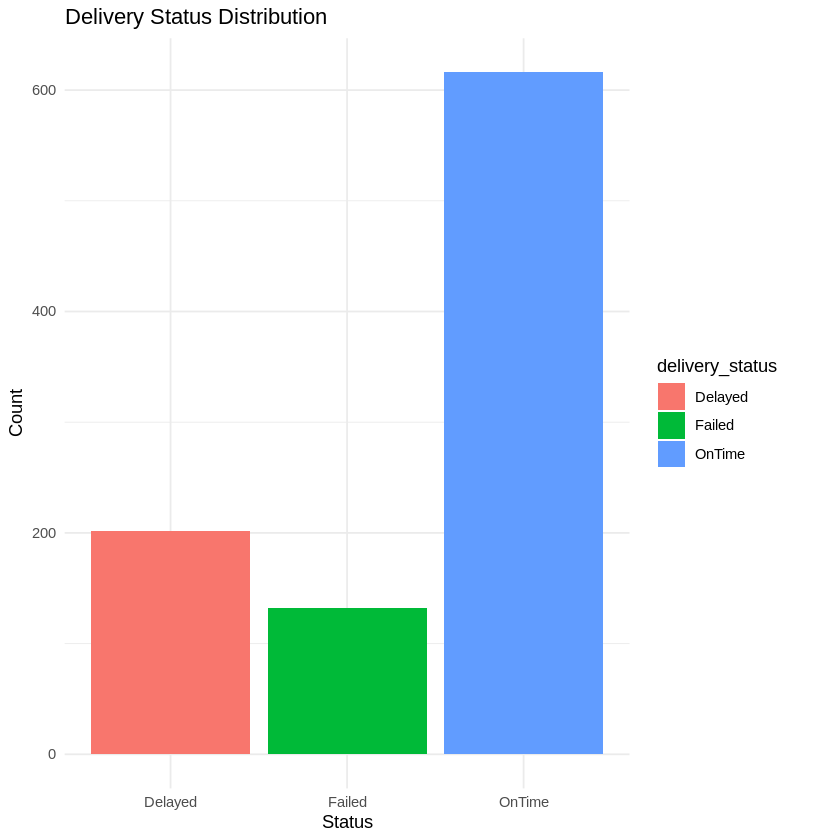

In [10]:
library(ggplot2)

# CHART 1: Distribution of delivery statuses
ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  labs(title = "Delivery Status Distribution",
       x = "Status", y = "Count") +
  theme_minimal()

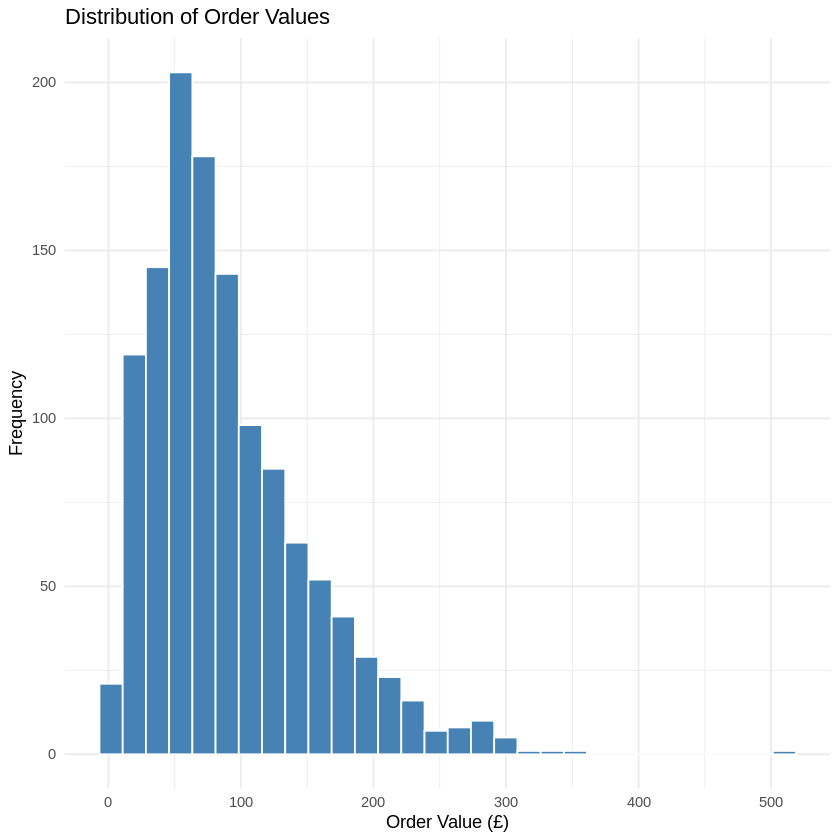

In [11]:
# CHART 2: Distribution of order values
ggplot(orders, aes(x = order_value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Order Values",
       x = "Order Value (£)", y = "Frequency") +
  theme_minimal()

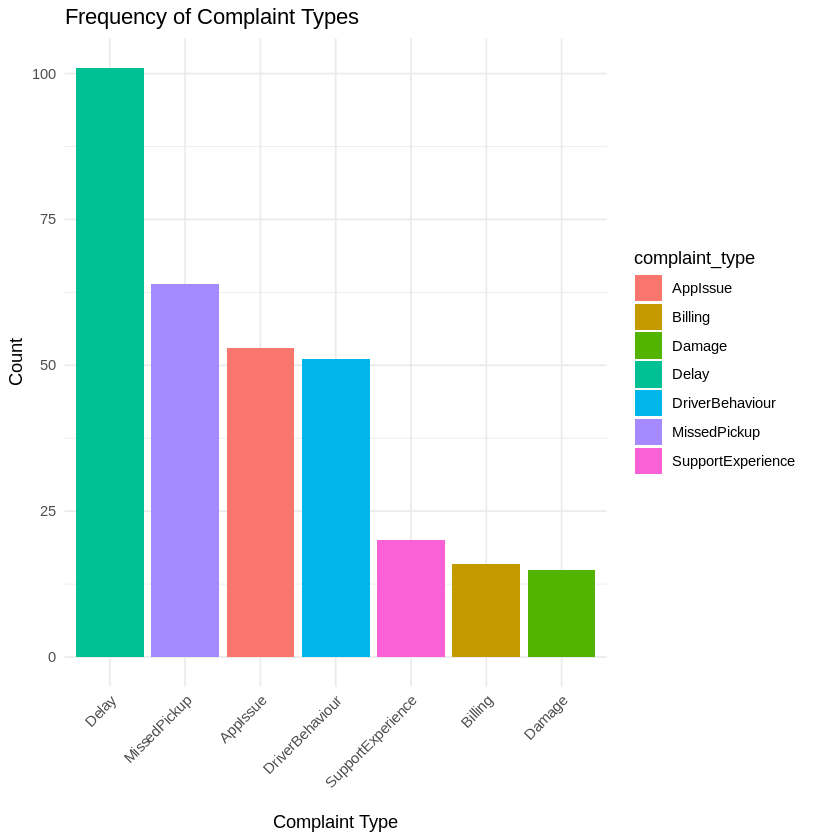

In [12]:
# CHART 3: Complaint types frequency
ggplot(complaints, aes(x = reorder(complaint_type, complaint_type,
                        function(x) -length(x)),
                        fill = complaint_type)) +
  geom_bar() +
  labs(title = "Frequency of Complaint Types",
       x = "Complaint Type", y = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [13]:
#Select
# Comparing revenue against cost per service type
# to identify which services are genuinely profitable
# This addresses the finance director's concern directly

select <- sqldf("
  SELECT o.service_type,
         COUNT(*)                                          AS total_orders,
         ROUND(SUM(o.order_value), 2)                     AS total_revenue,
         ROUND(SUM(d.fuel_or_charge_cost), 2)             AS total_cost,
         ROUND(SUM(o.order_value) -
               SUM(d.fuel_or_charge_cost), 2)             AS gross_profit,
         ROUND(AVG(d.customer_rating_post_delivery), 2)   AS avg_rating
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY gross_profit DESC
")

print(select)

  service_type total_orders total_revenue total_cost gross_profit avg_rating
1    Passenger          262      25463.36    3248.56     22214.80       3.85
2       Parcel          230      20735.44    3009.01     17726.43       3.90
3       Retail          224      19444.86    2906.27     16538.59       3.87
4     Business          126      12279.23    1655.91     10623.32       3.85
5      Medical          108       9344.88    1379.48      7965.40       3.84


In [14]:
# INSERT via rbind (sqldf operates on R data frames)
new_complaint <- data.frame(
  complaint_id='CP9999', customer_id='C0001',
  order_id='O00001', complaint_type='Delay',
  channel='App', severity='High',
  created_at='2026-06-06 5:00:00',
  status='Open', resolution_days=NA,
  compensation_amount=NA)
complaints <- rbind(complaints, new_complaint)

# Verify
sqldf("SELECT * FROM complaints WHERE complaint_id = 'CP9999'")


complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
CP9999,C0001,O00001,Delay,App,High,2026-06-06 5:00:00,Open,NA,NA


In [15]:
# UPDATE
complaints <- complaints %>%
  mutate(severity = case_when(
    status == 'Escalated' & resolution_days > 10 ~ 'Critical',
    TRUE ~ severity))

sqldf("SELECT severity, COUNT(*) AS n
       FROM complaints GROUP BY severity")


severity,n
<chr>,<int>
Critical,11
High,73
Low,68
Medium,169


In [16]:
# DELETE
complaints <- complaints[complaints$complaint_id != 'CP9999', ]
cat('Rows after deletion:', nrow(complaints), '\n')


Rows after deletion: 320 


In [17]:
# Delivery performance summary by status
sqldf('
  SELECT delivery_status,
    COUNT(*)                                   AS total,
    ROUND(AVG(route_distance_km), 2)           AS avg_dist_km,
    ROUND(AVG(fuel_or_charge_cost), 2)         AS avg_cost,
    ROUND(AVG(customer_rating_post_delivery),2) AS avg_rating,
    SUM(manual_route_override_count)           AS total_overrides
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total DESC
')


delivery_status,total,avg_dist_km,avg_cost,avg_rating,total_overrides
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>
OnTime,616,13.78,12.68,4.28,567
Delayed,202,14.67,13.14,3.11,217
Failed,132,13.37,13.15,3.05,137


In [18]:
# Cost per km and override rate by status
sqldf('
  SELECT delivery_status,
    ROUND(SUM(fuel_or_charge_cost)/SUM(route_distance_km),3) AS cost_per_km,
    ROUND(100.0 * SUM(CASE WHEN manual_route_override_count > 0
          THEN 1 ELSE 0 END) / COUNT(*), 1) AS override_rate_pct
  FROM deliveries
  GROUP BY delivery_status
')


delivery_status,cost_per_km,override_rate_pct
<chr>,<dbl>,<dbl>
Delayed,0.896,61.4
Failed,0.984,65.2
OnTime,0.920,55.4


In [19]:
# This is a simple COUNT query
result1 <- sqldf("
  SELECT delivery_status,
         COUNT(*) AS total
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total DESC
")

print(result1)

  delivery_status total
1          OnTime   616
2         Delayed   202
3          Failed   132


In [20]:
# Joining orders and deliveries together
# Then filter only failed ones and count by zone
result2 <- sqldf("
  SELECT o.pickup_zone,
         COUNT(*) AS failed_deliveries
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  WHERE d.delivery_status = 'Failed'
  GROUP BY o.pickup_zone
  ORDER BY failed_deliveries DESC
")

print(result2)

  pickup_zone failed_deliveries
1       NORTH                22
2     CENTRAL                22
3        EAST                19
4   RIVERSIDE                18
5        WEST                14
6       SOUTH                14
7     AIRPORT                12
8         CTR                11


In [21]:
result3 <- sqldf("
  SELECT d.base_zone,
         ROUND(AVG(d.driver_rating), 2) AS avg_rating,
         COUNT(*) AS num_drivers
  FROM drivers d
  GROUP BY d.base_zone
  ORDER BY avg_rating ASC
")

print(result3)

  base_zone avg_rating num_drivers
1     NORTH       4.09          36
2      EAST       4.12          21
3      WEST       4.12          20
4   CENTRAL       4.20          22
5   AIRPORT       4.21          19
6 RIVERSIDE       4.24          17
7       CTR       4.25           6
8     SOUTH       4.26          29


In [22]:
result4 <- sqldf("
  SELECT c.customer_id,
         COUNT(*) AS total_complaints,
         SUM(c.compensation_amount) AS total_compensation
  FROM complaints c
  GROUP BY c.customer_id
  ORDER BY total_complaints DESC
  LIMIT 10
")

print(result4)

   customer_id total_complaints total_compensation
1        C0368                4              77.51
2        C0626                3              36.23
3        C0573                3             111.42
4        C0545                3              73.60
5        C0421                3             118.98
6        C0372                3              71.89
7        C0282                3              74.63
8        C0242                3              75.75
9        C0191                3              62.76
10       C0172                3              61.49


In [23]:
result5 <- sqldf("
  SELECT v.maintenance_status,
         COUNT(DISTINCT v.vehicle_id)   AS total_vehicles,
         COUNT(DISTINCT i.incident_id)  AS total_incidents,
         ROUND(
           CAST(COUNT(DISTINCT i.incident_id) AS FLOAT) /
           NULLIF(COUNT(DISTINCT v.vehicle_id), 0),
         2) AS incidents_per_vehicle
  FROM vehicles v
  LEFT JOIN deliveries d ON v.vehicle_id = d.vehicle_id
  LEFT JOIN incidents  i ON d.delivery_id = i.delivery_id
  GROUP BY v.maintenance_status
  ORDER BY incidents_per_vehicle DESC
")
print(result5)

  maintenance_status total_vehicles total_incidents incidents_per_vehicle
1          Scheduled             17              46                  2.71
2           InRepair             36              84                  2.33
3             Active             67             150                  2.24


In [24]:
# NorthStar runs 5 service types: Passenger, Parcel, Retail, Business, Medical
# The finance director suspects some services lose money
# We compare: revenue (order_value) vs cost (fuel_or_charge_cost) per service type
# and also look at how often each service type fails

result6 <- sqldf("
  SELECT o.service_type,
         COUNT(DISTINCT o.order_id)            AS total_orders,
         ROUND(SUM(o.order_value), 2)          AS total_revenue,
         ROUND(SUM(d.fuel_or_charge_cost), 2)  AS total_cost,
         ROUND(SUM(o.order_value) - SUM(d.fuel_or_charge_cost), 2) AS gross_profit,
         ROUND(AVG(o.order_value), 2)          AS avg_order_value,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_count,
         ROUND(
           100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
           / COUNT(*),
         1) AS failure_rate_pct
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY gross_profit DESC
")

print(result6)

  service_type total_orders total_revenue total_cost gross_profit
1    Passenger          262      25463.36    3248.56     22214.80
2       Parcel          230      20735.44    3009.01     17726.43
3       Retail          224      19444.86    2906.27     16538.59
4     Business          126      12279.23    1655.91     10623.32
5      Medical          108       9344.88    1379.48      7965.40
  avg_order_value failed_count failure_rate_pct
1           97.19           38             14.5
2           90.15           25             10.9
3           86.81           28             12.5
4           97.45           25             19.8
5           86.53           16             14.8
